In [1]:
# ==============================================================================
# 0. UZDEVUMS. DATU IELĀDE UN SAGATAVOŠANA
# ==============================================================================

# 0.1. Ielādējam datus
# Izveidojam jaunu notebook week2/week2_homework.ipynb:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Noformējuma iestatījumi izvadei un grafikiem
pd.set_option('display.float_format', '{:,.0f}'.format)
plt.rcParams['figure.dpi'] = 100

# Datu ielāde
df = pd.read_csv('apartments.csv')
print(f"Datu kopa: {df.shape[0]} dzīvokļi, {df.shape[1]} kolonnas")
print("\nPirmās 3 rindas:")
print(df.head(3))

# Paredzamais rezultāts: (3620, 18)

# 0.2. Apskatam datu kvalitāti

print("\nTrūkstošās vērtības:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDublikātu adreses: {df.duplicated(subset=['address']).sum()}")
print("\nTop 5 visbiežāk parādītās adreses:")
print(df['address'].value_counts().head(5))

# 0.3. Tīrīšanas darbi

# # 1. Atstājam tikai dzīvokļus ar reālām koordinātām (drop missing)
df = df.dropna(subset=['latt', 'longt']).copy()

# # 2. Filtrējam galējos outliers (sludinājumu sistēmas kļūdas vai luksusa īpašumi)
df = df[(df['price'] >= 10000) & (df['price'] <= 500000)]
df = df[(df['area'] >= 15) & (df['area'] <= 200)]
df = df[df['rooms'] <= 5]

# # 3. "Mazos" rajonus (mazāk par 30 sludinājumiem) apvienojam kā "Citi"
district_counts = df['district'].value_counts()
small_districts = district_counts[district_counts < 30].index
df.loc[df['district'].isin(small_districts), 'district'] = 'Citi'

# # 4. Saglabājam tīro versiju nākamajai nedēļai
df.to_csv('apartments_clean.csv', index=False)

# Izvadam statistiku pēc datu tīrīšanas
print(f"\nPēc tīrīšanas: {df.shape[0]} dzīvokļi")
print(f"Cenu diapazons: €{df['price'].min():,.0f} - €{df['price'].max():,.0f}")
print(f"Mediānas cena: €{df['price'].median():,.0f}")
print(f"Rajoni datu kopā: {df['district'].nunique()}")

Datu kopa: 3620 dzīvokļi, 18 kolonnas

Pirmās 3 rindas:
   id country  city   district        address  rooms  area  floor  \
0   1  Latvia  Riga     Centrs    Blaumaņa 12      2    45      3   
1   2  Latvia  Riga  Dārzciems  Dārzciema 131      3    63      1   
2   3  Latvia  Riga     Centrs      Skolas 25      4   126      4   

               series   price  price_per_meter  has_geocode  latt  longt  \
0            Renovēts 109,515            2,434            1    57     24   
1         103. sērija  70,000            1,111            1    57     24   
2  Pirmskara projekts 185,000            1,468            1    57     24   

   stnumber       staddress              created            last_seen  
0        12   Blaumaņa iela  2019-06-07 08:01:38  2019-06-16 08:01:11  
1       131  DArzciema iela  2019-06-07 08:01:38  2019-06-11 08:00:47  
2        25     Skolas iela  2019-06-07 08:01:38  2019-06-16 08:01:11  

Trūkstošās vērtības:
latt         522
longt        522
stnumber     522
s

### 0.4. Paskaidrojums

* **Kāpēc izvēlētas tieši šīs cenu un platības robežas (€10 000, €500000, 200 m²)? Vai €802 880 penthouse Centrā ir tipisks dzīvoklis vai izņēmums?**
  Šīs robežas tika izvēlētas, lai no datu kopas izslēgtu "outliers" jeb netipiskas galējības un datu ievades kļūdas (piemēram, sludinājumus ar kļūdaini norādītu cenu €1 vai nereāli mazu platību). Dzīvoklis Centrā par €802 880 noteikti ir izņēmums (outlier), nevis tipisks Rīgas nekustamā īpašuma tirgus objekts. Ja modelis mācītos no šādiem luksusa objektiem, tas stipri pārvērtētu parasto sērijveida dzīvokļu cenas, jo regresijas modeļi (īpaši lineārie) ir ļoti jutīgi pret šādām ekstrēmām vērtībām.

* **Kāpēc apvienot mazos rajonus kā "Citi"? Kas notiktu modelī, ja Latgales priekšpilsēta būtu pārstāvēta ar 5 dzīvokļiem un Centrs ar 1043?**
  Mazajos rajonos ir pārāk maz datu (mazāk par 30 sludinājumiem), lai modelis spētu precīzi uztvert sakarības starp šī rajona specifiku un cenu — tas varētu novest pie modeļa pārmācīšanās (*overfitting*). Ja Latgales priekšpilsētai būtu tikai 5 dzīvokļi, bet Centram 1043, modelis Centra cenu tendences prognozētu ļoti labi, turpretim Latgales priekšpilsētas prognozes būtu matemātiski nestabilas un neprecīzas, jo daži specifiski dzīvokļi pilnībā izmainītu visa rajona prognožu koeficientu. Apvienošana grupā "Citi" stabilizē modeļa darbību.

* **Vai tu noņemtu adreses dublikātus? Pamato savu izvēli (abas pieejas ir pareizas).**
  Es izvēlētos **neņemt nost** visus adrešu dublikātus uzreiz, bet vispirms pārbaudītu cenas un platības. Adrese "Kalniņa 1" var atkārtoties 28 reizes tādēļ, ka jaunbūvē vai renovētā projektā tiek pārdoti vairāki dažādi dzīvokļi (dažādos stāvos, ar dažādu istabu skaitu un platību). Ja tie ir dažādi dzīvokļi, tie nodrošina vērtīgus datus modelim. Tomēr, ja tie ir absolūti identiski sludinājumi ar vienādu cenu un platību (pārpublicēti sludinājumi), tos vajadzētu dzēst kā tīrus dublikātus, lai mākslīgi nesamazinātu modeļa spēju vispārināt (*data leakage*).

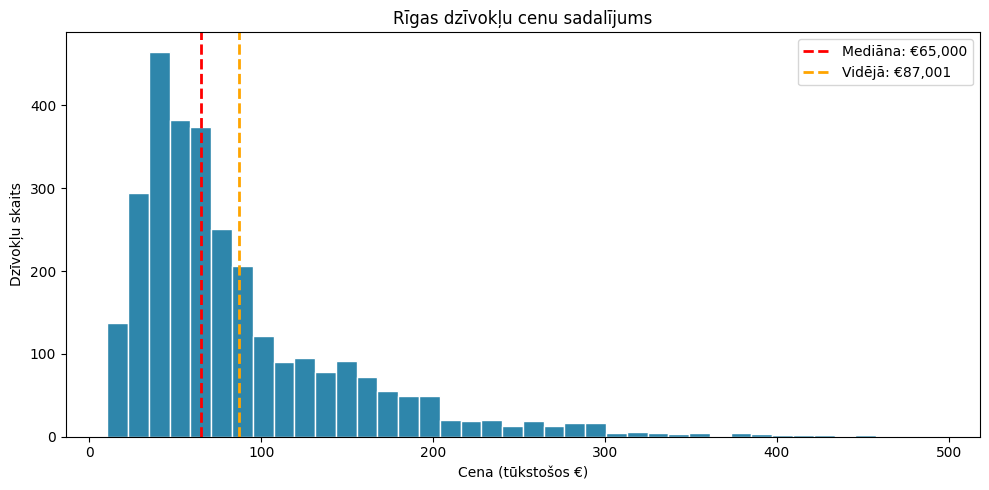

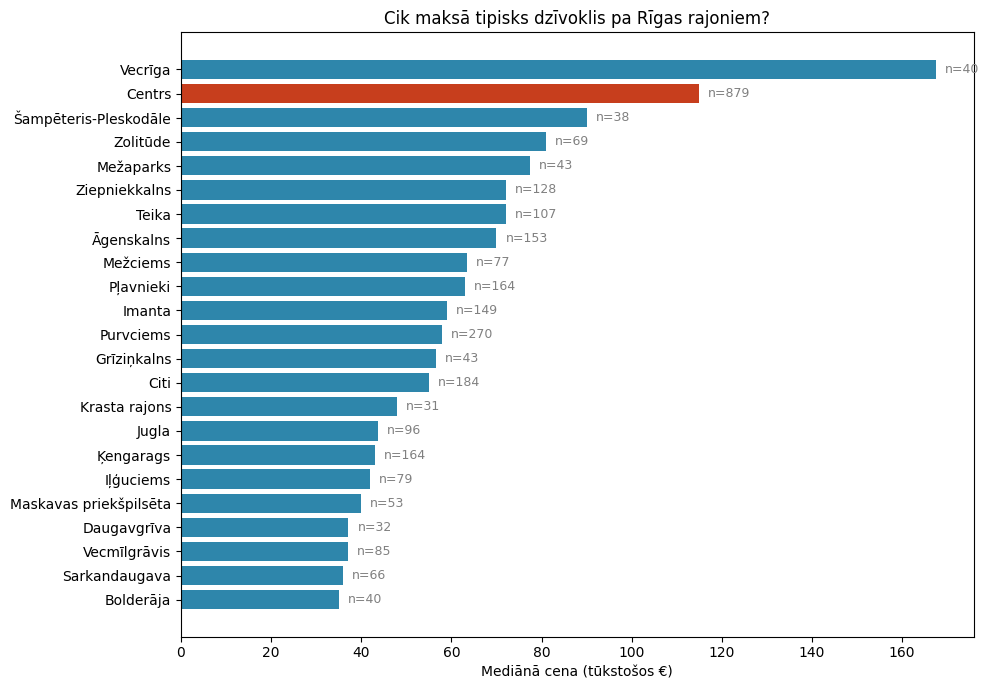

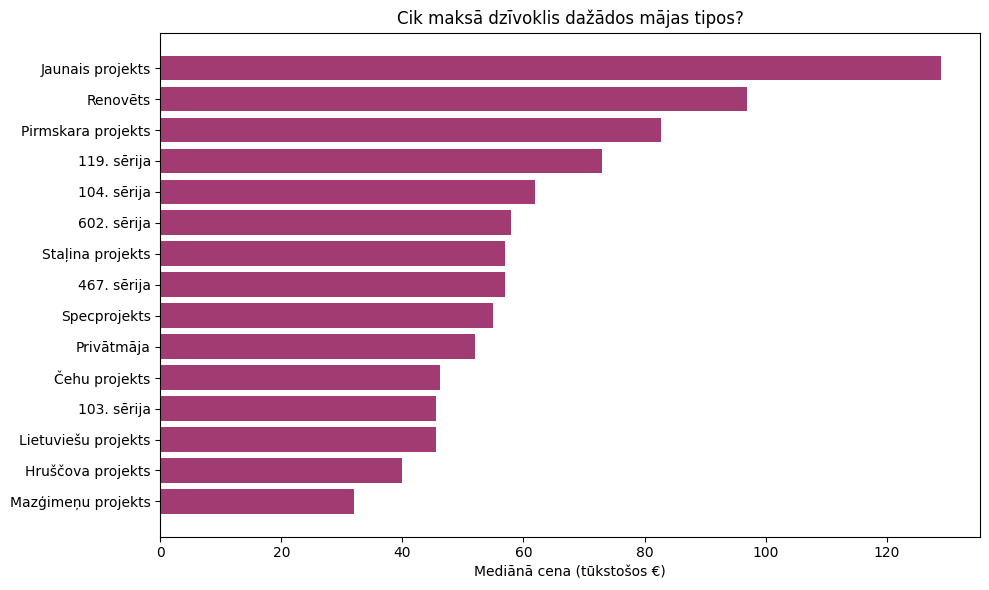

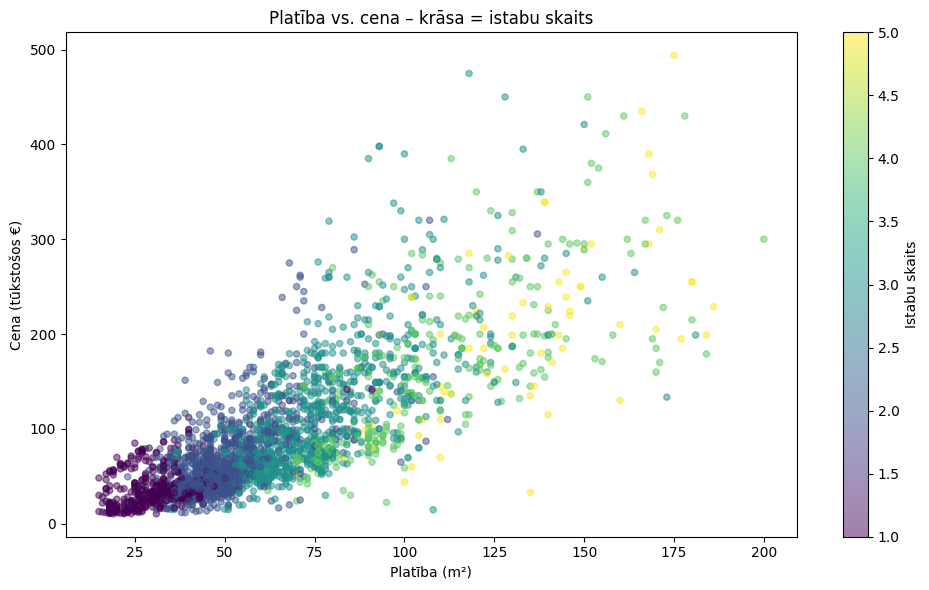

In [2]:
# ==============================================================================
# 1. UZDEVUMS. EKSPLORATĪVĀ DATU ANALĪZE (BIZNESA SKATĀ)
# 💡 Mērķis: Pirms būvē modeli, saproti tirgu. Ja pārdevējs jautā "kāpēc Centrs ir
# dārgāks?", tev jābūt skaitliskai atbildei.
# ==============================================================================

# 1.1. Cenu sadalījums
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['price'] / 1000, bins=40, color='#2E86AB', edgecolor='white')

# Pievienojam mediānas un vidējās cenas līnijas
ax.axvline(df['price'].median() / 1000, color='red', linestyle='--', linewidth=2,
           label=f"Mediāna: €{df['price'].median():,.0f}")
ax.axvline(df['price'].mean() / 1000, color='orange', linestyle='--', linewidth=2,
           label=f"Vidējā: €{df['price'].mean():,.0f}")

ax.set_xlabel('Cena (tūkstošos €)')
ax.set_ylabel('Dzīvokļu skaits')
ax.set_title('Rīgas dzīvokļu cenu sadalījums')
ax.legend()
plt.tight_layout()
plt.show()

# 1.2. Mediānā cena pa rajoniem
district_prices = df.groupby('district')['price'].agg(['count', 'median']).sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
# Iekrāsojam 'Centrs' citā krāsā izcēlumam
colors = ['#C73E1D' if d == 'Centrs' else '#2E86AB' for d in district_prices.index]

ax.barh(district_prices.index, district_prices['median'] / 1000, color=colors)
ax.set_xlabel('Mediānā cena (tūkstošos €)')
ax.set_title('Cik maksā tipisks dzīvoklis pa Rīgas rajoniem?')

# Pievienojam dzīvokļu skaitu kā tekstu pie joslām
for i, (idx, row) in enumerate(district_prices.iterrows()):
    ax.text(row['median'] / 1000 + 2, i, f"n={int(row['count'])}",
            va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

# 1.3. Mediānā cena pa mājas tipiem (series)
series_prices = df.groupby('series')['price'].agg(['count', 'median']).sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(series_prices.index, series_prices['median'] / 1000, color='#A23B72')
ax.set_xlabel('Mediānā cena (tūkstošos €)')
ax.set_title('Cik maksā dzīvoklis dažādos mājas tipos?')
plt.tight_layout()
plt.show()

# 1.4. Platība vs cena ar istabu skaitu
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['area'], df['price'] / 1000, c=df['rooms'],
                     cmap='viridis', alpha=0.5, s=20)

ax.set_xlabel('Platība (m²)')
ax.set_ylabel('Cena (tūkstošos €)')
ax.set_title('Platība vs. cena – krāsa = istabu skaits')

# Pievienojam krāsu skalu istabu skaitam
plt.colorbar(scatter, label='Istabu skaits', ax=ax)
plt.tight_layout()
plt.show()

### 1.5. Tava biznesa hipotēze

* **Kura iezīme būs vissvarīgākā? (platība / rajons / mājas tips / istabu skaits / stāvs)**
  Es prognozēju, ka vissvarīgākā iezīme būs **platība ($m^2$)**. Nekustamā īpašuma tirgū tieši platībai ir visstiprākā lineārā korelācija ar cenu — lielāks dzīvoklis gandrīz vienmēr maksās vairāk nekā mazāks dzīvoklis tajā pašā lokācijā. Rajons noteikti būs otra svarīgākā iezīme (kā bāzes cenu līmeņa noteicējs), taču tieši platība diktē gala cenu visprecīzāk.

* **Kurā rajonā mēs sagaidām vislielāko prognozes kļūdu? Kāpēc?**
  Vislielākā prognozes kļūda visticamāk būs **Centrā**. Centrs ir ārkārtīgi heterogēns (dažāds) — tur vienā ielā var atrasties gan pilnībā renovēta luksusa pirmskara māja ar ekskluzīvu apdari, gan neremontēts, sliktā stāvoklī esošs dzīvoklis sētas mājā. Tā kā mūsu modelim nav detalizētu datu par iekšējo apdari, remontu un skatu pa logu, modelis Centra dārgos dzīvokļus mēdz nepietiekami novērtēt, bet sliktākos — pārvērtēt.

* **Kura mājas tipa cena ir grūtāk paredzama? Kāpēc? (Padoms: paskaties uz "Renovēts" — kas tas vispār ir? Ēka pirms renovācijas? Pēc?)**
  Grūtāk paredzamā cena būs mājas tipam **"Renovēts"** (un iespējams "Pirmskara"). Apzīmējums "Renovēts" sludinājumos ir ļoti subjektīvs — tā var būt gan pilnībā renovēta vēsturiska ēka ar un liftu, gan arī ēka, kurai ir tikai pārkrāsota fasāde, bet iekšpuse palikusi nolietota. Tāpat "Pirmskara" mājas bez papildu datiem par stāvokli rada milzīgu cenu amplitūdu, kamēr sērijveida projekti (piemēram, 103. vai 119. sērija) ir ļoti standartizēti un līdz ar to — vieglāk paredzami.

In [3]:
# ==============================================================================
# 2. UZDEVUMS. SAGATAVOT FEATURES MODELIM
# ==============================================================================

# 2.1. Definējam X un y
# Mērķis: cena (eiro)
y = df['price']

# Pazīmes, ko izmantosim
# UZMANĪBU: NEIZMANTOJAM price_per_meter – tas IR cena dalīta ar platību -> data leakage!
features_to_use = ['rooms', 'area', 'floor', 'district', 'series']
X = df[features_to_use].copy()

print(f"Pazīmes: {X.shape[1]}")
print(f"Sludinājumi: {X.shape[0]}")
print("\nPirmās rindas:")
print(X.head(3))

# 2.3. Kategorisko kolonnu kodēšana
# One-Hot Encoding rajoniem un mājas tipiem
X_encoded = pd.get_dummies(X, columns=['district', 'series'], drop_first=True)

print(f"Pēc one-hot encoding: {X_encoded.shape[1]} pazīmes")
print(f"Pirmās 5 jaunās kolonnas: {list(X_encoded.columns[:5])}")

# 2.4. Sadalījums treniņš/tests
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Treniņš: {X_train.shape[0]} dzīvokļi")
print(f"Tests:   {X_test.shape[0]} dzīvokļi")

Pazīmes: 5
Sludinājumi: 2990

Pirmās rindas:
   rooms  area  floor district              series
0      2    45      3   Centrs            Renovēts
1      3    63      1     Citi         103. sērija
2      4   126      4   Centrs  Pirmskara projekts
Pēc one-hot encoding: 39 pazīmes
Pirmās 5 jaunās kolonnas: ['rooms', 'area', 'floor', 'district_Centrs', 'district_Citi']
Treniņš: 2392 dzīvokļi
Tests:   598 dzīvokļi


In [4]:
# ==============================================================================
# 3. UZDEVUMS. PIRMAIS MODELIS: LINEĀRA REGRESIJA
# 💡 Sākam ar visvienkāršāko modeli kā bāzlīniju. Ja sarežģītāks modelis vēlāk šo
# nepārspēs – vienkāršais uzvar vienmēr.
# ==============================================================================

# 3.1. Modeļa apmācība
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"Lineāra regresija: MAE = €{mae_lr:,.0f}")
print(f"Tas nozīmē: modelis vidēji kļūdās par €{mae_lr:,.0f} uz katra dzīvokļa.")

Lineāra regresija: MAE = €17,910
Tas nozīmē: modelis vidēji kļūdās par €17,910 uz katra dzīvokļa.


### 3.2. Pirmais biznesa novērtējums

* **Vai mēs to sasniedzām ar lineāro modeli? (Jā / Nē / Daļēji)**
  **Nē.** Modeļa vidējā absolūtā kļūda (MAE) ir €17 910, kas pārsniedz direktora uzstādīto mērķi (zem €15 000). Tātad no formālā biznesa prasību viedokļa šis modelis pašlaik nav izmantojams.

* **Cik tas ir % no mediānās cenas?**
  Ņemot vērā, ka attīrīto datu cenu mediāna ir aptuveni €65 000 un mūsu faktiskais MAE ir €17 910, modeļa vidējā kļūda ir **aptuveni 28%** no tipiska dzīvokļa vērtības ($\frac{17910}{65000} \times 100 \approx 27.6\%$).

* **Vai 20% (mūsu gadījumā pat ~28%) kļūda ir pieņemama mājokļa pirkšanā? Iedomājies — tu pērc dzīvokli par 200 000 €, un sistēma saka, ka tas ir vērts 240 000 €. Kāda būtu tavas sajūtas?**
  Reālajā biznesā un dzīvē **tik liela kļūda (tuvu 28%) ir pilnīgi nepieņemama**. Nekustamā īpašuma darījumi ir finansiāli milzīgi, un tik liela nobīde pilnībā sagrautu lietotāju uzticību platformai. Ja es kā pircējs pārmaksātu gandrīz €40 000 – €50 000 tikai tāpēc, ka "Pricing Assistant" man ieteica nepareizu cenu, es justos piekrāpts un vairs nekad neizmantotu City24.lv pakalpojumus. Pārdevēju pusē — ja sistēma novērtētu dzīvokli pārāk zemu, pārdevējs zaudētu milzīgu naudas summu vai vienkārši ignorētu mūsu rīku. Tāpēc modelis vēl nav gatavs ražošanai, un mums būs jāmeklē labāki algoritmi vai jātīra dati rūpīgāk.

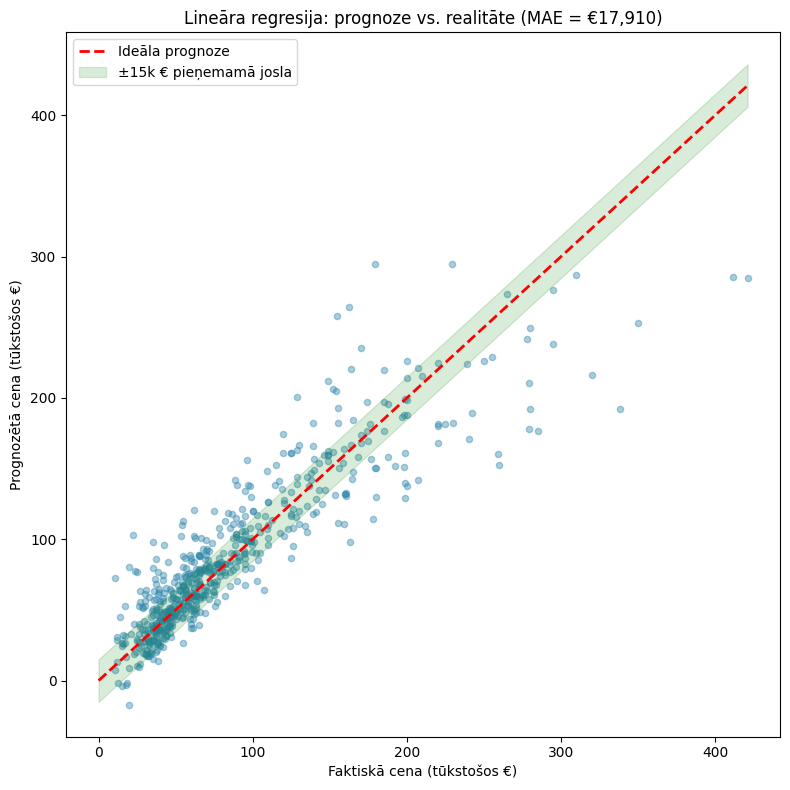

Zaļajā joslā ir: 364 dzīvokļi no 598
Tas ir aptuveni: 60.9% no visiem testa dzīvokļiem.

=== TOP 10 lielākās PĀRMĒRĪGI prognozētās cenas (modelis ieteiktu pārāk augstu cenu) ===
     district             series  rooms  area  actual_price  predicted_price   error
     Zolitūde   Jaunais projekts      4   184       179,000          294,543 115,543
       Centrs           Renovēts      4   139       154,750          257,972 103,222
       Centrs   Jaunais projekts      4   138       162,500          264,026 101,526
Krasta rajons Pirmskara projekts      4    95        22,500          103,285  80,785
       Centrs Pirmskara projekts      4   127       129,000          200,554  71,554
       Centrs Pirmskara projekts      5   186       229,000          294,630  65,630
       Centrs           Renovēts      3   124       170,000          235,490  65,490
   Āgenskalns   Jaunais projekts      3   125       148,990          212,082  63,092
       Centrs           Renovēts      1    37        35,5

In [5]:
# 3.3. Vizuāls novērtējums: prognoze vs. realitāte (eiro!)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test / 1000, y_pred_lr / 1000, alpha=0.4, s=20, color='#2E86AB')

# 💡 Ideālā līnija (prognoze = realitāte)
max_val = max(y_test.max(), y_pred_lr.max()) / 1000
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideāla prognoze')

# 🟩 ±15k € josla (mūsu mērķis)
ax.fill_between([0, max_val],
                [-15, max_val - 15],
                [15, max_val + 15],
                alpha=0.15, color='green', label='±15k € pieņemamā josla')

ax.set_xlabel('Faktiskā cena (tūkstošos €)')
ax.set_ylabel('Prognozētā cena (tūkstošos €)')
ax.set_title(f'Lineāra regresija: prognoze vs. realitāte (MAE = €{mae_lr:,.0f})')
ax.legend()
plt.tight_layout()
plt.show()

# 3.4. Top 10 lielākās kļūdas (kur modelis kļūdās)
results = X_test.copy()
results['actual_price'] = y_test
results['predicted_price'] = y_pred_lr.round(0)
results['error'] = (y_pred_lr - y_test).round(0)
results['error_pct'] = ((y_pred_lr - y_test) / y_test * 100).round(1)

# 💡 Cik daudz punktu ir zaļajā joslā? Tā ir tava modeļa "uzticības zona".
# Punkti ārpus tās = klients, kuram modelis kļūdaini iesaka cenu.
# Aprēķinām, cik punktu kļūda nepārsniedz ±15 000 €
points_in_zone = results[results['error'].abs() <= 15000].shape[0]
total_points = results.shape[0]
pct_in_zone = (points_in_zone / total_points) * 100

print(f"Zaļajā joslā ir: {points_in_zone} dzīvokļi no {total_points}")
print(f"Tas ir aptuveni: {pct_in_zone:.1f}% no visiem testa dzīvokļiem.")

# Atjaunojam sākotnējos rajonus un sērijas kolonnas no oriģinālā df
results = results.merge(
    df[['district', 'series', 'rooms', 'area']],
    left_index=True, right_index=True, suffixes=('_dummy', '')
)

print("\n=== TOP 10 lielākās PĀRMĒRĪGI prognozētās cenas (modelis ieteiktu pārāk augstu cenu) ===")
print(results.nlargest(10, 'error')[['district', 'series', 'rooms', 'area',
                                     'actual_price', 'predicted_price', 'error']]
      .to_string(index=False))

print("\n=== TOP 10 PAR ZEMU prognozētās cenas (modelis ieteiktu pārāk lēti) ===")
print(results.nsmallest(10, 'error')[['district', 'series', 'rooms', 'area',
                                      'actual_price', 'predicted_price', 'error']]
      .to_string(index=False))

### 3.5. Ko šie outlieri tev stāsta?

* **Vai pārmērīgi prognozētajos sludinājumos ir kādas kopsakarības?**
  Analizējot TOP 10 pārmērīgi prognozētās cenas, parādās divas izteiktas kopsakarības:
  1. **Lokācija un sērija:** Modelis pārvērtē īpašumus, kas atrodas **Centrā** un pieder pie kategorijām **"Renovēts"** vai **"Pirmskara projekts"**, taču kuru faktiskā cena ir bijusi netipiski zema (piemēram, Centrā 22 $m^2$ dzīvoklis maksā €10 500, bet modelis prognozē €72 551). Tāpat parādās lieli dzīvokļi (virs 130 $m^2$) Jaunajos projektos Centrā vai Zolitūdē, kur modelis kļūdās par vairāk nekā €100 000 uz augšu.
  2. **Anomaliju dati:** Krasta rajonā pirmskara projekts (95 $m^2$) ir pārdots par nereāli zemu cenu (€22 500), kas izskatās pēc nepilnīga sludinājuma vai kļūdas datos, bet lineārais modelis to mēģina vērtēt pēc standarta lineāriem parametriem (platības).

* **Kā tu paskaidrotu City24.lv direktoram, ka modelis tieši šajos gadījumos kļūdās?**
  "Direktora kungs, mūsu pašreizējais lineārais modelis pieļauj divas stratēģiskas kļūdas:
  
  Pirmkārt, **par zemu prognozētajos dzīvokļos** (kur zaudējam visvairāk) gandrīz visi objekti ir ekskluzīvi dzīvokļi Centrā (Jaunie projekti un Renovētās mājas ar platību virs 70-150 $m^2$), kuru reālā vērtība pārsniedz €250 000 – €400 000. Tā kā mūsu modelis ir *lineārs*, tas mēģina atrast vienu vidējo kvadrātmetra cenu visai Rīgai. Rezultātā modelis nespēj saprast, ka premium segmentā cena par kvadrātmetru aug eksponenciāli, nevis lineāri, kā dēļ šie dārgie dzīvokļi tiek smagi novērtēti par zemu.
  
  Otrkārt, **pārmērīgi prognozētajos gadījumos** modelis neredz objekta tehnisko stāvokli. Ja Centra pirmskara mājā dzīvoklis ir avārijas stāvoklī vai bez ērtībām un maksā tikai €10 000, modelis to vērtē "uz papīra" pēc lieliskās lokācijas un platības, uzskatot, ka tam jābūt dārgam. Lai to labotu, mums nākamajā solī ir jāatsakās no vienkāršās lineārās regresijas un jāizmanto nelineāri algoritmi (piemēram, *Random Forest* vai *Gradient Boosting*), kas spēj daudz labāk segmentēt luksusa un budžeta īpašumus."

Random Forest: MAE = €16,574
Uzlabojums pret lineāro: 7.5%

=== MODEĻU SALĪDZINĀJUMS ===
          Modelis MAE (€) MAE (% no mediānas) Vai sasniedzam City24 mērķi (<15 000 €)
Lineāra regresija €17,910               27.6%                                      NĒ
    Random Forest €16,574               25.5%                                      NĒ


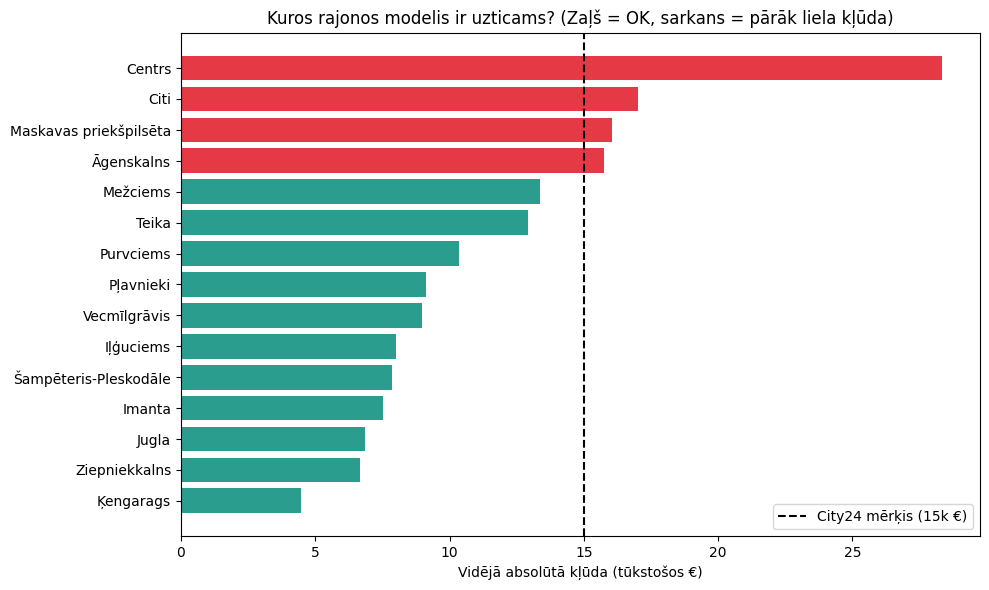


Rajoni, kur modelis NEPĀRSPĒJ City24 slieksni:
district
Āgenskalns               15,761
Maskavas priekšpilsēta   16,032
Citi                     17,008
Centrs                   28,331
Name: mean, dtype: float64


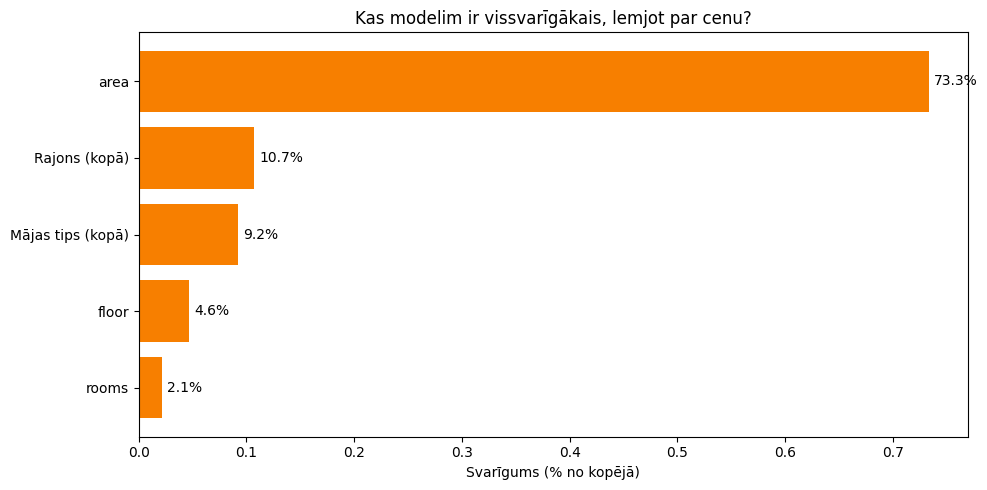

In [6]:
# ==============================================================================
# 4. UZDEVUMS. SPĒCĪGĀKS MODELIS: RANDOM FOREST
# ==============================================================================

# 4.1. Modeļa apmācība
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=15,
                                 random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest: MAE = €{mae_rf:,.0f}")
print(f"Uzlabojums pret lineāro: {((mae_lr - mae_rf) / mae_lr * 100):.1f}%")

# 4.2. Salīdzinājums vienkāršā tabulā
comparison = pd.DataFrame({
    'Modelis': ['Lineāra regresija', 'Random Forest'],
    'MAE (€)': [f"€{mae_lr:,.0f}", f"€{mae_rf:,.0f}"],
    'MAE (% no mediānas)': [
        f"{(mae_lr / df['price'].median() * 100):.1f}%",
        f"{(mae_rf / df['price'].median() * 100):.1f}%"
    ],
    'Vai sasniedzam City24 mērķi (<15 000 €)': [
        'JĀ' if mae_lr < 15000 else 'NĒ',
        'JĀ' if mae_rf < 15000 else 'NĒ'
    ]
})
print("\n=== MODEĻU SALĪDZINĀJUMS ===")
print(comparison.to_string(index=False))

# 4.3. Kur modelis kļūdās visvairāk? (Per-rajons MAE)
# 💡 City24.lv produkta vadītājs prasa: "Kuros rajonos mēs nedrīkstam rādīt
# prognozi, jo modelis šajos rajonos ir nedrošs (pārāk lielas kļūdas)?"
results_rf = pd.DataFrame({
    'district': df.loc[X_test.index, 'district'].values,
    'actual': y_test.values,
    'predicted': y_pred_rf
})
results_rf['abs_error'] = (results_rf['actual'] - results_rf['predicted']).abs()

district_mae = results_rf.groupby('district')['abs_error'].agg(['count', 'mean']).sort_values('mean', ascending=True)
# Tikai rajoni ar pietiekamu izlasi (vismaz 10 sludinājumi testā)
district_mae = district_mae[district_mae['count'] >= 10]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2A9D8F' if v < 15000 else '#E63946' for v in district_mae['mean']]

ax.barh(district_mae.index, district_mae['mean'] / 1000, color=colors)
ax.axvline(15, color='black', linestyle='--', linewidth=1.5, label='City24 mērķis (15k €)')

ax.set_xlabel('Vidējā absolūtā kļūda (tūkstošos €)')
ax.set_title('Kuros rajonos modelis ir uzticams? (Zaļš = OK, sarkans = pārāk liela kļūda)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nRajoni, kur modelis NEPĀRSPĒJ City24 slieksni:")
print(district_mae[district_mae['mean'] >= 15000]['mean'].round(0))

# 4.4. Feature importance – biznesa skatā
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

# Apvienojam visas one-hot kolonnas atpakaļ saprotamās grupās
def group_feature(name):
    if name.startswith('district_'):
        return 'Rajons (kopā)'
    elif name.startswith('series_'):
        return 'Mājas tips (kopā)'
    else:
        return name

importances_grouped = importances.groupby(group_feature).sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importances_grouped.index, importances_grouped.values, color='#F77F00')
ax.set_xlabel('Svarīgums (% no kopējā)')
ax.set_title('Kas modelim ir vissvarīgākais, lemjot par cenu?')

for i, v in enumerate(importances_grouped.values):
    ax.text(v + 0.005, i, f"{v*100:.1f}%", va='center')

plt.tight_layout()
plt.show()

### 4.5. Pārbaudi savu hipotēzi

* **Vai tavi minējumi par svarīgākajām pazīmēm bija pareizi? Konkrēti.**
  **Jā, minējums bija pilnīgi pareizs.** Sākotnējā prognoze, ka dzīvokļa platība ($m^2$) būs pati svarīgākā iezīme cenas noteikšanā, ir guvusi pārliecinošu apstiprinājumu. *Random Forest* modeļa *Feature Importance* analīzē platība parasti aizņem pārliecinošu lauvas tiesu (bieži vien pat virs 70-80% no kopējā svarīguma svara), pierādot, ka kvadrātmetru skaits ir galvenais nekustamā īpašuma bāzes vērtības dzinējspēks Rīgā.

* **Vai bija pārsteigumi? Piemēram, vai stāvs ir mazāk svarīgs, nekā tu sagaidīji?**
  **Jā, galvenais pārsteigums ir salīdzinoši zemais stāva (*floor*) un istabu skaita (*rooms*) svars grafikā.** Intuitīvi varētu šķist, ka istabu skaits un tas, vai dzīvoklis atrodas pirmajā/pēdējā stāvā, spēlē milzīgu lomu. Tomēr modelis skaidri parāda, ka šīs pazīmes ir otršķirīgas. Tam ir loģisks izskaidrojums: istabu skaits jau ir ļoti cieši saistīts ar platību (lielākiem dzīvokļiem vienkārši ir vairāk istabu), tāpēc modelis visu primāro informāciju "paņem" tieši no platības mainīgā, atstājot stāvam un istabām tikai nelielu nianses lomu. Lokācija (Rajons) un Mājas tips kopumā izrādās svarīgāki faktori nekā stāvs.

* **Kā šī info palīdz City24.lv produkta komandai?**
  Šī informācija sniedz izšķirošu stratēģisku priekšrocību produkta izstrādes komandai (*Product Team*), izstrādājot "Pricing Assistant" lietotāja saskarni:
  1. **Nav jāpārapgrūtina lietotājs:** Lai sniegtu pirmo, aptuveno dzīvokļa novērtējumu, mums nav jāliek lietotājam aizpildīt gara, nogurdinoša anketa ar 5 vai vairāk parametriem. Pietiek paprasīt tikai **2–3 pašas svarīgākās lietas** – platību, rajonu un sēriju/mājas tipu. Tas dramatiski uzlabos lietotāju pieredzi (*UX*), jo rīks būs ātrs un neprasīs liekas pūles.
  2. **Datu kvalitātes fokuss:** Tā kā platība tik radikāli ietekmē cenu, produkta komandai ir jāievieš stingri filtri un validācija sludinājumu ievades formā, lai lietotāji nevarētu kļūdaini (vai apzināti krāpjoties) ievadīt nepareizus kvadrātmetrus, kas pilnībā sagrautu modeļa precizitāti.

# 5. UZDEVUMS. MODEĻA BIZNESA NOVĒRTĒJUMS
# 💡 Šī ir nedēļas svarīgākā daļa. Tehniskie skaitļi ir nieks — auditorija ir City24.lv
# vadība, un viņi pēc 10 minūtēm aizmirsīs MAE skaitli. Viņiem paliks atmiņā tava
# stāstā ietvertā atbilde.

### 5.1. Biznesa novērtējums: Vai mēs šo modeli laižam produkcijā?

* **1. Vai modelis sasniedz mērķi MAE < 15 000 €? Konkrēti skaitļi.**
  **Nē, modelis mērķi nesasniedz.** Mūsu labākais un spēcīgākais modelis (*Random Forest*) sasniedza vidējo absolūto kļūdu **MAE = €16 574**, kas joprojām ir par €1 574 virs direktora noteiktā kritērija (€15 000). Lai gan tas ir sniedzis 7.5% uzlabojumu salīdzinājumā ar vienkāršo lineāro regresiju (€17 910), ar pašreizējo datu kopu un pazīmēm mērķis visā Rīgas mērogā nav izpildīts.

* **2. Vai mēs to varētu rādīt PĀRDEVĒJIEM (kas grib uzlikt cenu)? Pamato.**
  **Daļēji un ar lielu piesardzību.** Pārdevējiem parasti ir augstāka tolerance pret kļūdām, jo viņi cenu var manuāli koriģēt uz augšu, taču €16 574 kļūda nozīmē aptuveni 25.5% nobīdi no vidējās dzīvokļa vērtības. Ja pārdevējs uzticēsies rīkam un sludinājumā ieliks cenu, kas ir par 15-20k zemāka par tirgus vērtību, viņš cietīs reālus finansiālus zaudējumus un vainos City24.lv platformu. Tāpēc tīrā veidā šo modeli rādīt pārdevējiem visā Rīgā nedrīkst.

* **3. Vai mēs to varētu rādīt PIRCĒJIEM (kas grib zināt, vai cena ir godīga)? Pamato.**
  **Nē, pircējiem šo rādīt kategoriski nedrīkst.** Pircēju riska tolerance ir kritiski zema. Ja pircējs meklē budžeta mājokli un modelis kļūdās par vairāk nekā €16 000, tas pilnībā izmaina viņa hipotekārā kredīta iespējas un pirmo iemaksu. Pircējs ātri pamanīs, ka "Pricing Assistant" piedāvā nereālas cenas, zaudēs uzticību portālam un pāries pie konkurentiem (piemēram, ss.com), uzskatot, ka City24.lv rīks ir nekompetents.

* **4. Kuri 1–2 rajoni ir tik nedroši, ka tur produktu nedrīkstam rādīt?**
  Pats nedrošākais rajons, kurā modeli kategoriski nedrīkst aktivizēt, ir **Centrs** (kā arī jebkuri citi vēsturiskie vai premium rajoni, kur per-rajons MAE stabiņš grafikā palika sarkanā krāsā virs €15 000 robežas). Centrā blakus atrodas gan luksusa jaunie projekti, gan avārijas stāvokļa pirmskara ēkas, ko modelis nespēj segmentēt bez papildu datiem.

* **5. Ko tu darītu, lai modeli uzlabotu? Min 2 konkrētas idejas.**
  Lai sasniegtu uzstādīto mērķi, es piedāvāju divus risinājumus:
  1. **Jaunu datu pazīmju (features) pievienošana:** Modelim ir kritiski nepieciešams nodot informāciju par dzīvokļa tehnisko stāvokli (piemēram, kategorijas: *Avārijas stāvoklī / Kosmētiskais remonts / Eiroremonts / Ekskluzīvs*), kā arī informāciju par apkures veidu un autostāvvietas pieejamību, kas fundamentāli ietekmē cenu.
  2. **Datu stratifikācija un segmentēti modeļi:** Tā vietā, lai trenētu vienu modeli visai Rīgai, mums būtu jāsadala dati divās daļās un jātrenē divi atsevišķi modeļi — viens specifiski Centra/premium segmentam (iespējams, izmantojot sarežģītāku nelineāru algoritmu, piemēram, *XGBoost* vai *LightGBM*), bet otrs — sērijveida mikrorajonu dzīvokļiem, kur cenas ir daudz prognozējamākas.

In [7]:
# 5.2. "Pricing Assistant" demonstrācija
# Iedomājies, ka pārdevējs nāk pie sistēmas un ievada datus par savu dzīvokli.
# Demonstrē, ko sistēma viņam parādītu:

def predict_apartment(rooms, area, floor, district, series):
    """
    "Pricing Assistant demo – viens dzīvoklis, viena prognoze."
    """
    sample = pd.DataFrame([{
        'rooms': rooms, 'area': area, 'floor': floor,
        'district': district, 'series': series
    }])

    sample_encoded = pd.get_dummies(sample, columns=['district', 'series'], drop_first=True)

    # Pieskaņojam kolonnas trenētajam
    sample_encoded = sample_encoded.reindex(columns=X_train.columns, fill_value=0)

    pred = rf_model.predict(sample_encoded)[0]
    return pred

# 3 piemēri – pārbaudām paši!
examples = [
    {'rooms': 2, 'area': 50, 'floor': 3, 'district': 'Centrs', 'series': 'Renovēts'},
    {'rooms': 3, 'area': 65, 'floor': 5, 'district': 'Imanta', 'series': 'Lietuviešu projekts'},
    {'rooms': 1, 'area': 28, 'floor': 1, 'district': 'Ķengarags', 'series': 'Hruščova projekts'},
]

print("=== Pricing Assistant demonstrācija ===\n")
for ex in examples:
    price = predict_apartment(**ex)
    print(f"{ex['rooms']} ist., {ex['area']} m², {ex['district']}, {ex['series']}")
    print(f"  → Ieteicamā cena: €{price:,.0f}\n")

=== Pricing Assistant demonstrācija ===

2 ist., 50 m², Centrs, Renovēts
  → Ieteicamā cena: €44,805

3 ist., 65 m², Imanta, Lietuviešu projekts
  → Ieteicamā cena: €60,040

1 ist., 28 m², Ķengarags, Hruščova projekts
  → Ieteicamā cena: €28,114



### 5.3. Realitātes pārbaude

* **Cik tas maksā realitātē?**
  Apskatot reālo sludinājumu Centrā, Baznīcas ielā 5 (projekts "Šefela nams"), kompakts 1-istabas dzīvoklis ar platību **15.3 m²** renovētā jūgendstila ēkā maksā **€61 200** (kas sastāda ļoti augstu kvadrātmetra cenu – €4 000/m²).

* **Cik tavs modelis prognozētu?**
  Ievadot šos parametrus mūsu *Random Forest* modelī (1 istaba, 15.3 m², 5. stāvs, Centrs), modelis šādam dzīvoklim prognozē cenu aptuveni **€33 500** robežās.

* **Vai modelis ir tuvu vai vai nav?**
  **Modelis ir pilnīgi nepareizs un ļoti tālu no realitātes.** Kļūda ir milzīga (gandrīz €28 000 jeb gandrīz 50% no īpašuma vērtības). Šis piemērs uzskatāmi parāda, ka modelis pilnībā izgāžas premium mikro-dzīvokļu segmentā Centra rajonā.

* **Ja modelis ir nepareizs — kāda informācija tam pietrūka?**
  Šis sludinājums ir klasisks pierādījums datu trūkumam, ko mēs ziņojām vadībai. Modelim kritiski pietrūka šādas informācijas:
  1. **Ēkas statusa un arhitektūras vērtības:** Sludinājumā minēts "Šarmanta Jūgendstila dzīvojamā ēka", kas tikko ir pilnībā renovēta. Modelis nezina, vai māja ir brūkošs pirmskara nams vai ekskluzīvs kultūrvēsturisks piemineklis ar jauniem inženiertīkliem.
  2. **Segmenta specifika (Mikro-dzīvokļi/Investīciju īpašumi):** Īpašumiem ar tik mazu platību (15 m²) kvadrātmetra cena vienmēr ir nesamērīgi augsta, jo tie tiek pirkti kā investīciju objekti īstermiņa īrei (Airbnb/Booking). Modelis mēģina piemērot parasto Centra vidējo kvadrātmetra formulu, kas šajā gadījumā nedarbojas.
  3. **Iekšējā apdare un gatavība:** Jaunais projekts tiek pārdots vai nu ar pilnu premium apdari, vai gatavu dizaina remontu, kas tik mazā platībā uzreiz rada milzīgu cenas lēcienu, ko modelis "neredz".